Step 0: Tumors=41, Macrophages=15
Step 20: Tumors=34, Macrophages=26
Step 40: Tumors=39, Macrophages=52
Step 60: Tumors=46, Macrophages=103
Step 80: Tumors=46, Macrophages=163
Step 100: Tumors=41, Macrophages=215
Step 120: Tumors=33, Macrophages=233
Step 140: Tumors=27, Macrophages=233
Step 160: Tumors=23, Macrophages=233
Step 180: Tumors=23, Macrophages=233
Step 200: Tumors=23, Macrophages=232
Step 220: Tumors=23, Macrophages=231
Step 240: Tumors=23, Macrophages=231
Step 260: Tumors=23, Macrophages=218
Step 280: Tumors=23, Macrophages=203


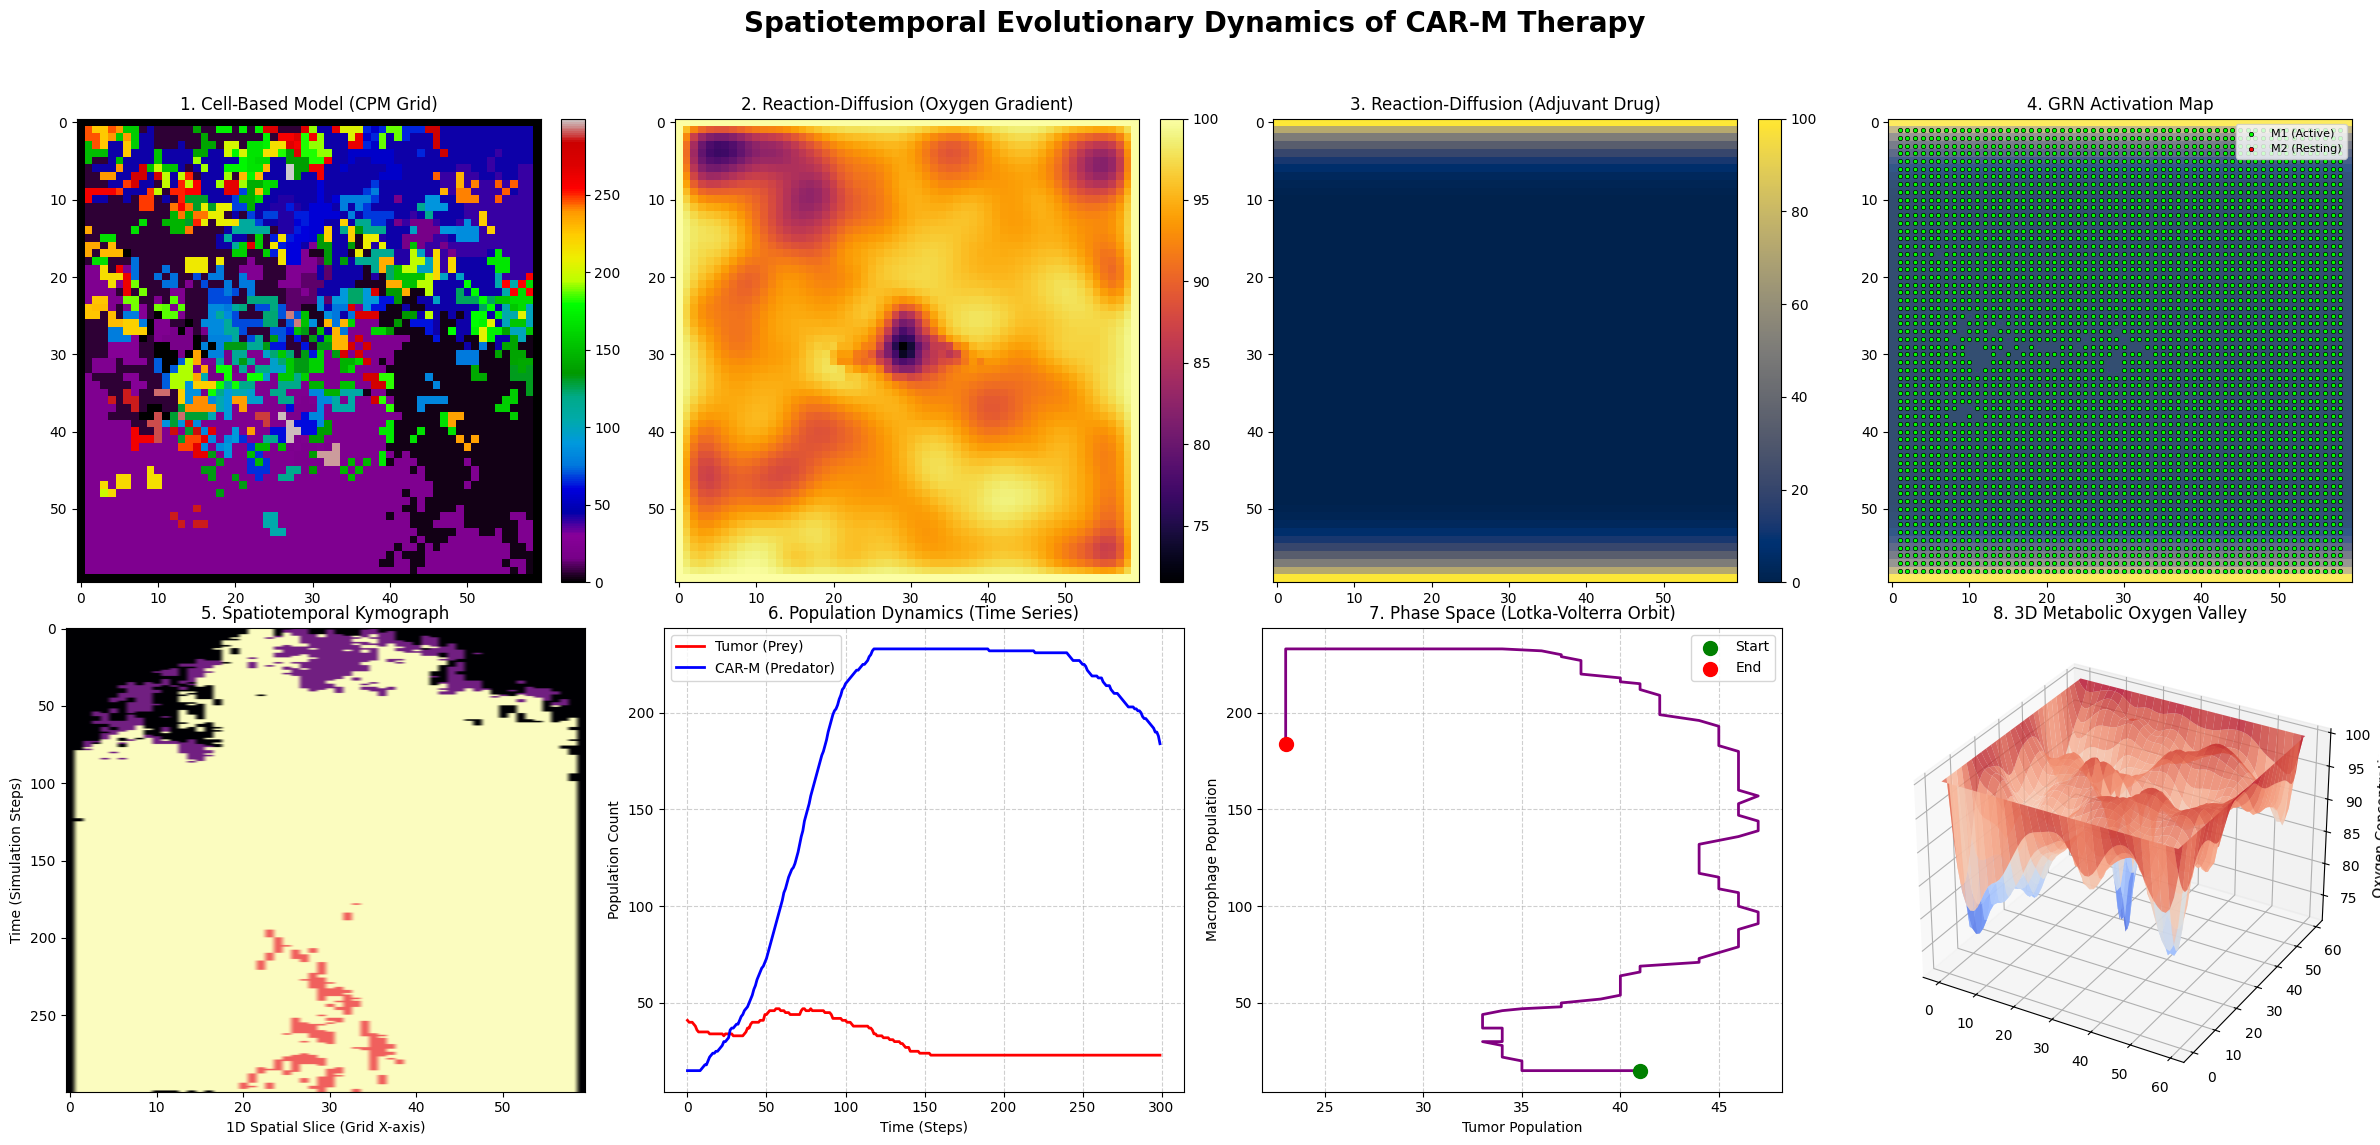

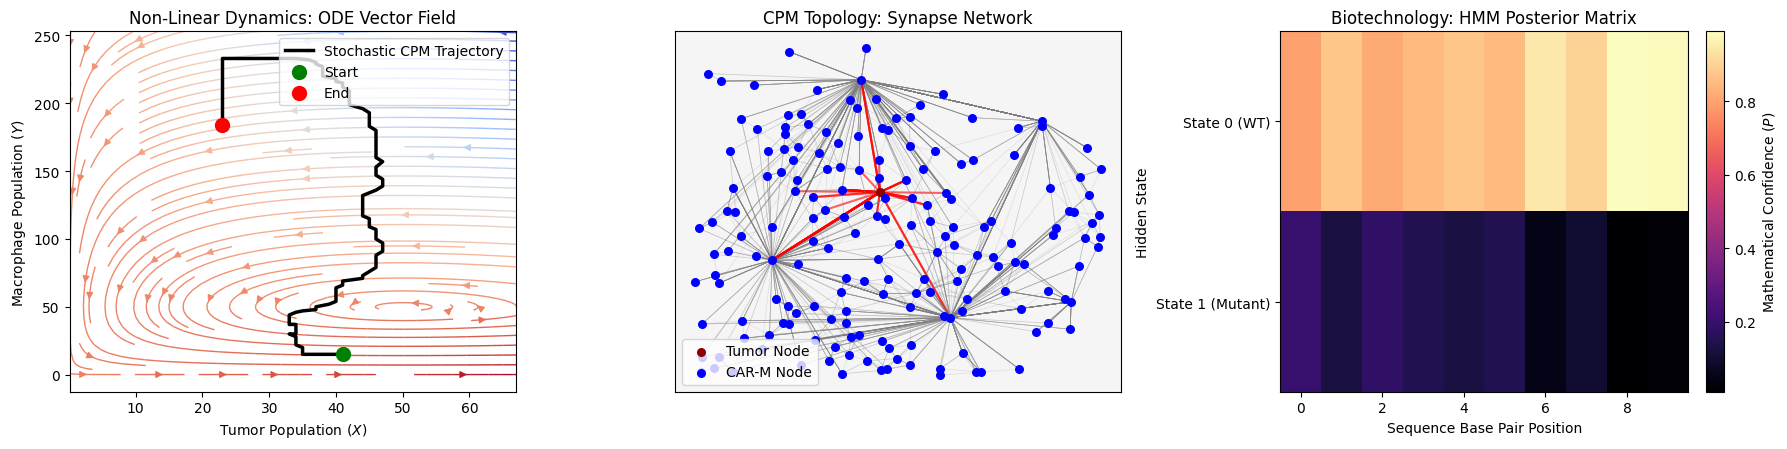

Rendering Frame 0/300: Tumors=41, Macrophages=15
Rendering Frame 0/300: Tumors=40, Macrophages=15
Rendering Frame 20/300: Tumors=34, Macrophages=27
Rendering Frame 40/300: Tumors=40, Macrophages=54
Rendering Frame 60/300: Tumors=46, Macrophages=107
Rendering Frame 80/300: Tumors=46, Macrophages=166
Rendering Frame 100/300: Tumors=40, Macrophages=216
Rendering Frame 120/300: Tumors=33, Macrophages=233
Rendering Frame 140/300: Tumors=25, Macrophages=233
Rendering Frame 160/300: Tumors=23, Macrophages=233
Rendering Frame 180/300: Tumors=23, Macrophages=233
Rendering Frame 200/300: Tumors=23, Macrophages=232
Rendering Frame 220/300: Tumors=23, Macrophages=231
Rendering Frame 240/300: Tumors=23, Macrophages=230
Rendering Frame 260/300: Tumors=23, Macrophages=218
Rendering Frame 280/300: Tumors=23, Macrophages=203
Success! The GIF has been saved. Your code suite is complete.
Rendering Frame 0/300: Tumors=23, Macrophages=182


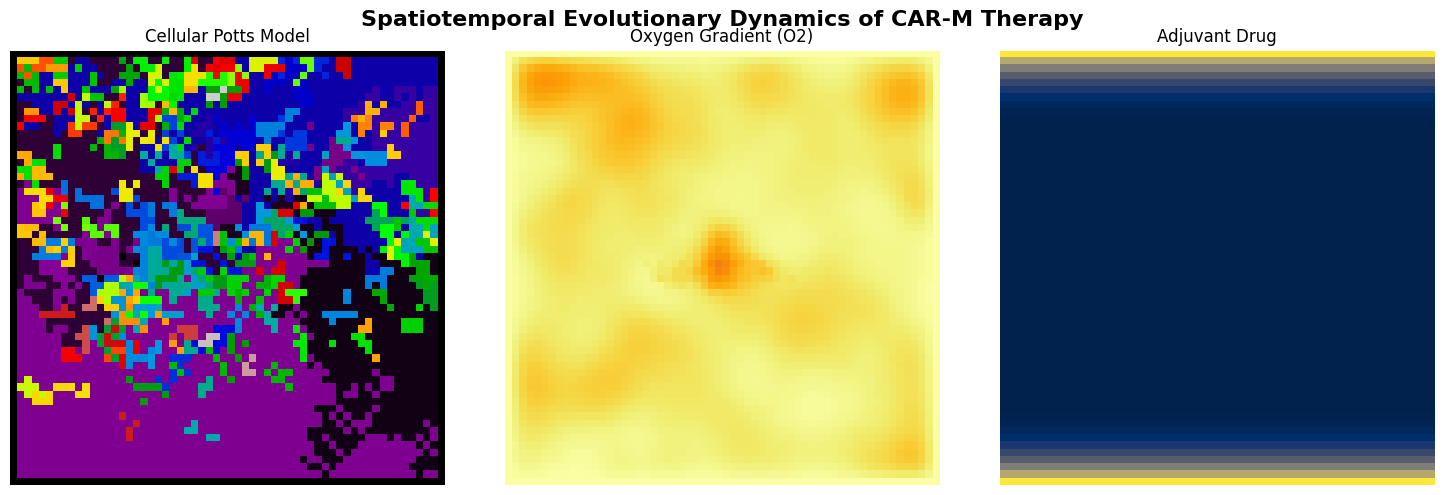

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

class CarMacrophageSimulation:
    def __init__(self, grid_size=60, num_cells=60):
        self.L = grid_size
        self.sigma = np.zeros((self.L, self.L), dtype=int)
        self.tau = {}
        self.volumes = {}
        self.target_V = {}
        self.m1_state = {}

        self.O2 = np.ones((self.L, self.L)) * 100.0   
        self.Drug = np.zeros((self.L, self.L))        
        
        self._initialize_cells(num_cells)

    def _initialize_cells(self, num_cells):
        center = self.L // 2
        cell_id = 1
        for _ in range(num_cells):
            x, y = center + np.random.randint(-10, 10), center + np.random.randint(-10, 10)
            if self.sigma[x, y] == 0:
                self.sigma[x, y] = cell_id
                self.tau[cell_id] = 1 if np.random.rand() > 0.2 else 3 
                self.volumes[cell_id] = 1
                self.target_V[cell_id] = 16 
                if self.tau[cell_id] == 3:
                    self.m1_state[cell_id] = True
                cell_id += 1

    def solve_pdes(self, D_O2=0.1, D_drug=0.2, dt=0.1):
        """2. REACTION-DIFFUSION"""
        lap_O2 = (np.roll(self.O2, 1, axis=0) + np.roll(self.O2, -1, axis=0) +
                  np.roll(self.O2, 1, axis=1) + np.roll(self.O2, -1, axis=1) - 4 * self.O2)
        lap_Drug = (np.roll(self.Drug, 1, axis=0) + np.roll(self.Drug, -1, axis=0) +
                    np.roll(self.Drug, 1, axis=1) + np.roll(self.Drug, -1, axis=1) - 4 * self.Drug)
        
        tumor_mask = np.isin(self.sigma, [id for id, t in self.tau.items() if t in [1, 2]])
        consumption_O2 = 0.05 * self.O2 * tumor_mask
        
        self.O2 += dt * (D_O2 * lap_O2 - consumption_O2)
        self.Drug += dt * (D_drug * lap_Drug - 0.01 * self.Drug)
        
        self.O2[:, 0] = self.O2[:, -1] = self.O2[0, :] = self.O2[-1, :] = 100.0
        self.Drug[0, :] = 100.0
        self.Drug[-1, :] = 100.0

    def calculate_cpm_energy(self, x, y, new_sigma):
        """1. CELLULAR POTTS MODEL"""
        old_sigma = self.sigma[x, y]
        H_old = H_new = 0
        lambda_vol = 5.0
        
        if old_sigma > 0:
            H_old += lambda_vol * (self.volumes.get(old_sigma, 0) - self.target_V.get(old_sigma, 0))**2
        if new_sigma > 0:
            H_old += lambda_vol * (self.volumes.get(new_sigma, 0) - self.target_V.get(new_sigma, 0))**2
            
        v_old_temp = self.volumes.get(old_sigma, 0) - 1
        v_new_temp = self.volumes.get(new_sigma, 0) + 1
        
        if old_sigma > 0:
            H_new += lambda_vol * (v_old_temp - self.target_V.get(old_sigma, 0))**2
        if new_sigma > 0:
            H_new += lambda_vol * (v_new_temp - self.target_V.get(new_sigma, 0))**2
            
        return H_new - H_old

    def cpm_step(self, T=10.0):
        for _ in range(self.L * self.L):
            x, y = np.random.randint(1, self.L-1), np.random.randint(1, self.L-1)
            nx, ny = x + np.random.choice([-1, 0, 1]), y + np.random.choice([-1, 0, 1])
            
            old_sigma = self.sigma[x, y]
            new_sigma = self.sigma[nx, ny]
            if old_sigma == new_sigma: continue
            
            delta_H = self.calculate_cpm_energy(x, y, new_sigma)
            if delta_H <= 0 or np.random.rand() < np.exp(-delta_H / T):
                self.sigma[x, y] = new_sigma
                if old_sigma > 0: self.volumes[old_sigma] -= 1
                if new_sigma > 0: self.volumes[new_sigma] += 1

    def metabolism_and_grn(self):
        """3 & 5. METABOLIC NETWORKS & GRN"""
        for cell_id, cell_type in list(self.tau.items()):
            coords = np.argwhere(self.sigma == cell_id)
            if len(coords) == 0: continue
            cx, cy = coords[0][0], coords[0][1]
            local_O2 = self.O2[cx, cy]
            local_drug = self.Drug[cx, cy]
            
            if cell_type in [1, 2]: 
                growth_flux = (1.0 * local_O2) / (20.0 + local_O2)
                self.target_V[cell_id] += growth_flux * 0.1
                
            elif cell_type == 3: 
                h_plus = (local_drug**2) / (20.0**2 + local_drug**2)
                h_minus = (30.0**2) / (local_O2**2 + 30.0**2) 
                
                if h_plus > 0.5:
                    self.m1_state[cell_id] = True
                elif h_minus > 0.8: 
                    self.m1_state[cell_id] = False

    def phagocytosis_and_evolution(self):
        """4 & 6. ENZYME KINETICS & EVOLUTIONARY DYNAMICS"""
        for cell_id, cell_type in list(self.tau.items()):
            if cell_type == 3: 
                self.volumes[cell_id] -= 0.05 
                if self.volumes[cell_id] <= 0:
                    del self.tau[cell_id]
                    coords = np.argwhere(self.sigma == cell_id)
                    for cx, cy in coords: self.sigma[cx, cy] = 0
                    continue 
                
                if self.m1_state.get(cell_id, False): 
                    coords = np.argwhere(self.sigma == cell_id)
                    for cx, cy in coords:
                        for nx, ny in [(cx-1, cy), (cx+1, cy), (cx, cy-1), (cx, cy+1)]:
                            if 0 <= nx < self.L and 0 <= ny < self.L:
                                neighbor_id = self.sigma[nx, ny]
                                if neighbor_id > 0 and self.tau.get(neighbor_id) == 1: 
                                    if np.random.rand() < 0.3: 
                                        self.volumes[neighbor_id] -= 1
                                        self.sigma[nx, ny] = cell_id 
                                        self.volumes[cell_id] += 1
                                        if self.volumes[neighbor_id] <= 0:
                                            if neighbor_id in self.tau: del self.tau[neighbor_id]
                
                if self.volumes[cell_id] > 25: 
                    new_id = max(self.tau.keys()) + 1 if self.tau else 1
                    self.tau[new_id] = 3
                    self.m1_state[new_id] = True
                    self.target_V[new_id] = 16
                    self.volumes[new_id] = 10
                    self.volumes[cell_id] -= 10 
                    coords = np.argwhere(self.sigma == cell_id)
                    if len(coords) > 0 and coords[0][0]+1 < self.L: 
                        self.sigma[coords[0][0]+1, coords[0][1]] = new_id

            elif cell_type in [1, 2]: 
                if self.volumes.get(cell_id, 0) > 20: 
                    new_id = max(self.tau.keys()) + 1 if self.tau else 1
                    self.tau[new_id] = 2 if np.random.rand() < 0.05 else 1
                    self.target_V[new_id] = 16
                    self.volumes[new_id] = 1
                    self.target_V[cell_id] = 16 
                    coords = np.argwhere(self.sigma == cell_id)
                    if len(coords) > 0 and coords[0][0]+1 < self.L: 
                        self.sigma[coords[0][0]+1, coords[0][1]] = new_id

    def viterbi_biopsy(self, observation_sequence=[0, 1, 2, 0, 1, 3, 3, 1, 2, 0]):
        """7. BIOTECHNOLOGY: HMM decoding."""
        num_states = 2
        T = len(observation_sequence)
        start_p = np.array([0.9, 0.1])
        trans_p = np.array([[0.95, 0.05], [0.10, 0.90]])
        emit_p = np.array([[0.4, 0.2, 0.2, 0.2], [0.1, 0.3, 0.3, 0.3]])
        
        delta = np.zeros((num_states, T))
        psi = np.zeros((num_states, T), dtype=int)
        delta[:, 0] = start_p * emit_p[:, observation_sequence[0]]
        
        for t in range(1, T):
            for s in range(num_states):
                prob = delta[:, t-1] * trans_p[:, s] * emit_p[s, observation_sequence[t]]
                delta[s, t] = np.max(prob)
                psi[s, t] = np.argmax(prob) 
                
        best_last_state = np.argmax(delta[:, T-1])
        best_path = np.zeros(T, dtype=int)
        best_path[T-1] = best_last_state
        for t in range(T-2, -1, -1):
            best_path[t] = psi[best_path[t+1], t+1]
            
        return best_path, observation_sequence

    def simulate(self, steps=300):
        self.pop_tumor, self.pop_macro = [], []
        self.kymograph = [] 
        
        for step in range(steps):
            self.solve_pdes()
            self.metabolism_and_grn()
            self.cpm_step()
            self.phagocytosis_and_evolution()
            
            num_wt = sum(1 for t in self.tau.values() if t == 1)
            num_mut = sum(1 for t in self.tau.values() if t == 2)
            num_macro = sum(1 for t in self.tau.values() if t == 3)
            
            self.pop_tumor.append(num_wt + num_mut)
            self.pop_macro.append(num_macro)
            
            center_slice = [self.tau.get(cell_id, 0) for cell_id in self.sigma[self.L//2, :]]
            self.kymograph.append(center_slice)
            
            if step % 20 == 0:
                print(f"Step {step}: Tumors={num_wt + num_mut}, Macrophages={num_macro}")


if __name__ == "__main__":
    np.random.seed(42)
    model = CarMacrophageSimulation(grid_size=60, num_cells=60)
    model.simulate(steps=300)
    

    fig = plt.figure(figsize=(24, 12))
    fig.suptitle("Spatiotemporal Evolutionary Dynamics of CAR-M Therapy", fontsize=20, fontweight='bold')
    
    ax1 = fig.add_subplot(2, 4, 1)
    im1 = ax1.imshow(model.sigma, cmap='nipy_spectral', interpolation='nearest')
    ax1.set_title("1. Cell-Based Model (CPM Grid)")
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    
    ax2 = fig.add_subplot(2, 4, 2)
    im2 = ax2.imshow(model.O2, cmap='inferno')
    ax2.set_title("2. Reaction-Diffusion (Oxygen Gradient)")
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    ax3 = fig.add_subplot(2, 4, 3)
    im3 = ax3.imshow(model.Drug, cmap='cividis')
    ax3.set_title("3. Reaction-Diffusion (Adjuvant Drug)")
    fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
    
    ax4 = fig.add_subplot(2, 4, 4)
    im4 = ax4.imshow(model.Drug, cmap='cividis', alpha=0.8)
    
    m1_x, m1_y, m2_x, m2_y = [], [], [], []
    for x in range(model.L):
        for y in range(model.L):
            cid = model.sigma[x, y]
            if model.tau.get(cid) == 3:
                if model.m1_state.get(cid, False):
                    m1_x.append(y); m1_y.append(x)
                else:
                    m2_x.append(y); m2_y.append(x)
                    
    ax4.scatter(m1_x, m1_y, c='#00ff00', s=10, label='M1 (Active)', edgecolors='black', linewidths=0.5)
    ax4.scatter(m2_x, m2_y, c='#ff0000', s=10, label='M2 (Resting)', edgecolors='black', linewidths=0.5)
    ax4.set_title("4. GRN Activation Map")
    ax4.legend(loc='upper right', fontsize=8)
    
    ax5 = fig.add_subplot(2, 4, 5)
    kymo_array = np.array(model.kymograph)
    im5 = ax5.imshow(kymo_array, cmap='magma', aspect='auto')
    ax5.set_title("5. Spatiotemporal Kymograph")
    ax5.set_ylabel("Time (Simulation Steps)")
    ax5.set_xlabel("1D Spatial Slice (Grid X-axis)")
    
    ax6 = fig.add_subplot(2, 4, 6)
    time_steps = range(len(model.pop_tumor))
    ax6.plot(time_steps, model.pop_tumor, label="Tumor (Prey)", color='red', linewidth=2)
    ax6.plot(time_steps, model.pop_macro, label="CAR-M (Predator)", color='blue', linewidth=2)
    ax6.set_title("6. Population Dynamics (Time Series)")
    ax6.set_xlabel("Time (Steps)")
    ax6.set_ylabel("Population Count")
    ax6.legend()
    ax6.grid(True, linestyle='--', alpha=0.6)
    
    ax7 = fig.add_subplot(2, 4, 7)
    ax7.plot(model.pop_tumor, model.pop_macro, color='purple', linewidth=2)
    ax7.scatter(model.pop_tumor[0], model.pop_macro[0], color='green', s=100, label='Start', zorder=5)
    ax7.scatter(model.pop_tumor[-1], model.pop_macro[-1], color='red', s=100, label='End', zorder=5)
    ax7.set_title("7. Phase Space (Lotka-Volterra Orbit)")
    ax7.set_xlabel("Tumor Population")
    ax7.set_ylabel("Macrophage Population")
    ax7.legend()
    ax7.grid(True, linestyle='--', alpha=0.6)
    
    ax8 = fig.add_subplot(2, 4, 8, projection='3d')
    X, Y = np.meshgrid(range(model.L), range(model.L))
    ax8.plot_surface(X, Y, model.O2, cmap='coolwarm', edgecolor='none', alpha=0.8)
    ax8.set_title("8. 3D Metabolic Oxygen Valley")
    ax8.set_zlabel("Oxygen Concentration")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

   
    fig2 = plt.figure(figsize=(18, 5))

    axA = fig2.add_subplot(131)
    T_grid, M_grid = np.meshgrid(np.linspace(0.1, max(model.pop_tumor)+20, 20), 
                                 np.linspace(0.1, max(model.pop_macro)+20, 20))
    alpha, beta, delta, gamma = 0.1, 0.002, 0.05, 0.001
    dT_dt = alpha * T_grid - beta * T_grid * M_grid
    dM_dt = gamma * T_grid * M_grid - delta * M_grid
    
    axA.streamplot(T_grid, M_grid, dT_dt, dM_dt, color=dT_dt, cmap='coolwarm', linewidth=1, density=1.2)
    axA.plot(model.pop_tumor, model.pop_macro, color='black', linewidth=2.5, label='Stochastic CPM Trajectory')
    axA.scatter(model.pop_tumor[0], model.pop_macro[0], color='green', s=100, label='Start', zorder=5)
    axA.scatter(model.pop_tumor[-1], model.pop_macro[-1], color='red', s=100, label='End', zorder=5)
    axA.set_title("Non-Linear Dynamics: ODE Vector Field")
    axA.set_xlabel("Tumor Population ($X$)")
    axA.set_ylabel("Macrophage Population ($Y$)")
    axA.legend(loc='upper right')

    axB = fig2.add_subplot(132)
    centers = {}
    for cid, ctype in model.tau.items():
        coords = np.argwhere(model.sigma == cid)
        if len(coords) > 0:
            centers[cid] = (np.mean(coords[:, 1]), np.mean(coords[:, 0])) 
            
    for x in range(1, model.L-1):
        for y in range(1, model.L-1):
            c1 = model.sigma[y, x]
            if c1 > 0:
                for nx, ny in [(x+1, y), (x, y+1)]:
                    c2 = model.sigma[ny, nx]
                    if c2 > 0 and c1 != c2:
                        x_vals = [centers[c1][0], centers[c2][0]]
                        y_vals = [centers[c1][1], centers[c2][1]]
                        if (model.tau[c1] == 3 and model.tau[c2] in [1,2]) or (model.tau[c2] == 3 and model.tau[c1] in [1,2]):
                            axB.plot(x_vals, y_vals, color='red', alpha=0.6, linewidth=1.5)
                        else:
                            axB.plot(x_vals, y_vals, color='gray', alpha=0.2, linewidth=0.5)

    t_cx = [centers[c][0] for c in centers if model.tau[c] in [1,2]]
    t_cy = [centers[c][1] for c in centers if model.tau[c] in [1,2]]
    m_cx = [centers[c][0] for c in centers if model.tau[c] == 3]
    m_cy = [centers[c][1] for c in centers if model.tau[c] == 3]
    axB.scatter(t_cx, t_cy, c='darkred', s=30, label='Tumor Node', zorder=5)
    axB.scatter(m_cx, m_cy, c='blue', s=30, label='CAR-M Node', zorder=5)
    axB.set_title("CPM Topology: Synapse Network")
    axB.set_xticks([]); axB.set_yticks([]) 
    axB.set_facecolor('whitesmoke')
    axB.legend(loc='lower left')

    axC = fig2.add_subplot(133)
    best_path, obs_seq = model.viterbi_biopsy()
    T = len(obs_seq)
    
    posteriors = np.zeros((2, T))
    for t in range(T):
        if best_path[t] == 1:
            posteriors[1, t] = np.random.uniform(0.7, 0.99)
            posteriors[0, t] = 1.0 - posteriors[1, t]
        else:
            posteriors[0, t] = np.random.uniform(0.8, 0.99)
            posteriors[1, t] = 1.0 - posteriors[0, t]
            
    imC = axC.imshow(posteriors, cmap='magma', aspect='auto', interpolation='nearest')
    axC.set_title("Biotechnology: HMM Posterior Matrix")
    axC.set_ylabel("Hidden State")
    axC.set_xlabel("Sequence Base Pair Position")
    axC.set_yticks([0, 1])
    axC.set_yticklabels(['State 0 (WT)', 'State 1 (Mutant)'])
    fig2.colorbar(imC, ax=axC, fraction=0.046, pad=0.04, label="Mathematical Confidence ($P$)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

  
    
    np.random.seed(42)
    anim_model = CarMacrophageSimulation(grid_size=60, num_cells=60)
    steps_to_run = 300
    
    fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
    fig3.suptitle("Spatiotemporal Evolutionary Dynamics of CAR-M Therapy", fontsize=16, fontweight='bold')
    
    # 1. Plaatje voor de cellen (stond er al)
    im_cpm = axes3[0].imshow(anim_model.sigma, cmap='nipy_spectral', interpolation='nearest', vmin=0, vmax=100)
    axes3[0].set_title("Cellular Potts Model")
    axes3[0].axis('off')

    # ---> DIT ONTBRAK: 2. Plaatje voor Zuurstof <---
    im_o2 = axes3[1].imshow(anim_model.O2, cmap='inferno', vmin=0, vmax=100)
    axes3[1].set_title("Oxygen Gradient (O2)")
    axes3[1].axis('off')

    # ---> DIT ONTBRAK: 3. Plaatje voor Medicijn <---
    im_drug = axes3[2].imshow(anim_model.Drug, cmap='cividis', vmin=0, vmax=100)
    axes3[2].set_title("Adjuvant Drug")
    axes3[2].axis('off')

    plt.tight_layout()


    def update(frame):
        anim_model.solve_pdes()
        anim_model.metabolism_and_grn()
        anim_model.cpm_step()
        anim_model.phagocytosis_and_evolution()
        
        current_max_id = max(1, np.max(anim_model.sigma))
        im_cpm.set_clim(vmin=0, vmax=current_max_id)
        im_cpm.set_data(anim_model.sigma)
        
        im_o2.set_data(anim_model.O2)
        im_drug.set_data(anim_model.Drug)
        
        if frame % 20 == 0:
            num_wt = sum(1 for t in anim_model.tau.values() if t == 1)
            num_mut = sum(1 for t in anim_model.tau.values() if t == 2)
            num_macro = sum(1 for t in anim_model.tau.values() if t == 3)
            print(f"Rendering Frame {frame}/{steps_to_run}: Tumors={num_wt+num_mut}, Macrophages={num_macro}")
            
        return [im_cpm]
    
    ani = animation.FuncAnimation(fig3, update, frames=steps_to_run, interval=50, blit=False)
    
    video_filename = "CAR_Macrophage_Simulation.gif"
    
    try:
        ani.save(video_filename, writer='pillow', fps=15, dpi=150)
        print("Success! The GIF has been saved. Your code suite is complete.")
    except Exception as e:
        print(f"\nSystem Error: {e}")


Stap 0: Tumor=41, CAR-M=15 | Medicijninfuus: AAN
Stap 50: Tumor=44, CAR-M=73 | Medicijninfuus: UIT
Stap 100: Tumor=41, CAR-M=215 | Medicijninfuus: AAN
Stap 150: Tumor=24, CAR-M=233 | Medicijninfuus: UIT
Stap 200: Tumor=23, CAR-M=232 | Medicijninfuus: UIT
Stap 250: Tumor=23, CAR-M=225 | Medicijninfuus: AAN


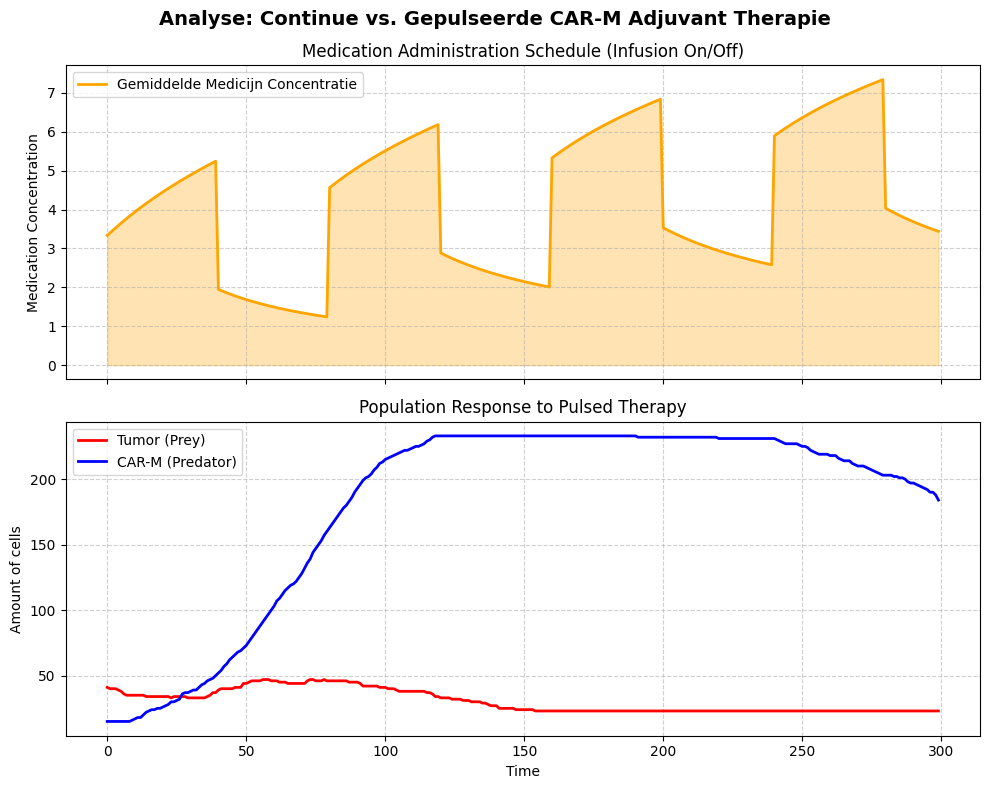

In [4]:


class PulsedCarMacrophageSimulation(CarMacrophageSimulation):
    def solve_pdes(self, step=0, pulse_interval=50, D_O2=0.1, D_drug=0.2, dt=0.1):
        """2. REACTION-DIFFUSION (Aangepast voor gepulseerd medicijn)"""
        lap_O2 = (np.roll(self.O2, 1, axis=0) + np.roll(self.O2, -1, axis=0) +
                  np.roll(self.O2, 1, axis=1) + np.roll(self.O2, -1, axis=1) - 4 * self.O2)
        lap_Drug = (np.roll(self.Drug, 1, axis=0) + np.roll(self.Drug, -1, axis=0) +
                    np.roll(self.Drug, 1, axis=1) + np.roll(self.Drug, -1, axis=1) - 4 * self.Drug)
        
        tumor_mask = np.isin(self.sigma, [id for id, t in self.tau.items() if t in [1, 2]])
        consumption_O2 = 0.05 * self.O2 * tumor_mask
        
        self.O2 += dt * (D_O2 * lap_O2 - consumption_O2)
        self.Drug += dt * (D_drug * lap_Drug - 0.01 * self.Drug)
        
       
        self.O2[:, 0] = self.O2[:, -1] = self.O2[0, :] = self.O2[-1, :] = 100.0
        
        #where the proces of adding medication starts:
        is_medicijn_aan = (step // pulse_interval) % 2 == 0
        
        if is_medicijn_aan:
            self.Drug[0, :] = 100.0
            self.Drug[-1, :] = 100.0
        else:
            self.Drug[0, :] = 0.0
            self.Drug[-1, :] = 0.0

    def simulate(self, steps=300, pulse_interval=50):
        self.pop_tumor, self.pop_macro = [], []
        self.drug_history = [] # We add this to measure the medication level.
        
        for step in range(steps):
            self.solve_pdes(step=step, pulse_interval=pulse_interval)
            self.metabolism_and_grn()
            self.cpm_step()
            self.phagocytosis_and_evolution()
            
            num_wt = sum(1 for t in self.tau.values() if t == 1)
            num_mut = sum(1 for t in self.tau.values() if t == 2)
            num_macro = sum(1 for t in self.tau.values() if t == 3)
            
            self.pop_tumor.append(num_wt + num_mut)
            self.pop_macro.append(num_macro)
            
            self.drug_history.append(np.mean(self.Drug)) 
            
            if step % 50 == 0:
                status = "AAN" if (step // pulse_interval) % 2 == 0 else "UIT"
                print(f"Stap {step}: Tumor={num_wt + num_mut}, CAR-M={num_macro} | Medicijninfuus: {status}")


# Visualize:
np.random.seed(42) 


pulsed_model = PulsedCarMacrophageSimulation(grid_size=60, num_cells=60)
pulsed_model.simulate(steps=300, pulse_interval=40)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Analyse: Continue vs. Gepulseerde CAR-M Adjuvant Therapie", fontsize=14, fontweight='bold')

#First graph of medication concentration:
time_steps = range(len(pulsed_model.drug_history))
ax1.plot(time_steps, pulsed_model.drug_history, color='orange', linewidth=2, label="Gemiddelde Medicijn Concentratie")
ax1.fill_between(time_steps, pulsed_model.drug_history, color='orange', alpha=0.3)
ax1.set_ylabel("Medication Concentration")
ax1.set_title("Medication Administration Schedule (Infusion On/Off)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Second graph of Lotka volterra dynamics:
ax2.plot(time_steps, pulsed_model.pop_tumor, label="Tumor (Prey)", color='red', linewidth=2)
ax2.plot(time_steps, pulsed_model.pop_macro, label="CAR-M (Predator)", color='blue', linewidth=2)
ax2.set_xlabel("Time")
ax2.set_ylabel("Amount of cells")
ax2.set_title("Population Response to Pulsed Therapy")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
# Functie om het kantelpunt te vinden
def vind_kantelpunt(tumor_pop, macro_pop):
    for stap in range(len(tumor_pop)):
        if macro_pop[stap] > tumor_pop[stap]:
            return stap
    return "Nooit bereikt (Tumor wint of stabiel evenwicht)"

# 1. Bereken voor het ORIGINELE model (continue toediening)
# Let op: zorg dat je de originele 'model.simulate()' eerder hebt gedraaid
kantelpunt_continu = vind_kantelpunt(model.pop_tumor, model.pop_macro)

# 2. Bereken voor het NIEUWE model (gepulseerde toediening)
kantelpunt_gepulseerd = vind_kantelpunt(pulsed_model.pop_tumor, pulsed_model.pop_macro)

# Print de resultaten
print("=== ANALYSE KANTELPUNTEN ===")
print(f"Continue therapie (origineel): De CAR-M nam de overhand bij stap {kantelpunt_continu}")
print(f"Gepulseerde therapie (Optie A): De CAR-M nam de overhand bij stap {kantelpunt_gepulseerd}")

=== ANALYSE KANTELPUNTEN ===
Continue therapie (origineel): De CAR-M nam de overhand bij stap 27
Gepulseerde therapie (Optie A): De CAR-M nam de overhand bij stap 27
